# 稳态热模型，采取拟合参数的方法

## import需要的库

In [1]:
import os,gzip,pickle
from utils.keys import DataDir,Cols
import numpy as np
import pandas as pd
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch
from torch.utils.data import random_split

# 设置字体
matplotlib.rcParams['font.family'] = 'Microsoft YaHei, Times New Roman'
# 全局设置字号
plt.rcParams.update({
    'font.size': 20,  # 基础字号
    'axes.titlesize': 20,  # 标题字号
    'axes.labelsize': 20,  # 坐标轴标签字号
    'xtick.labelsize': 20,  # x轴刻度标签字号
    'ytick.labelsize': 20,  # y轴刻度标签字号
    'legend.fontsize': 18  # 图例字号
})
# 解决负号显示问题
matplotlib.rcParams['axes.unicode_minus'] = False

## 读取数据

In [2]:
with gzip.open(
    r'D:\Devs\Single_Stack_MLJ\data\processed\XINYUAN\包头1000方数据1#2025-12.01-12.30 gzip',
    'rb'
) as f:
    df_XY = pickle.load(f)

### 滤波

In [3]:
from scipy.ndimage.filters import gaussian_filter1d

# 设置高斯滤波的标准差
sigma = 1.0

# 进行高斯滤波
df_XY[Cols.temp_out] = gaussian_filter1d(df_XY[Cols.temp_out], sigma)

C:\Users\Orz\AppData\Local\Temp\ipykernel_16144\3728954166.py:1: DeprecationWarning: Please import `gaussian_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter1d


### 计算生成温度变化值

In [4]:
df_XY[Cols.delta_temp_out] = df_XY[Cols.temp_out].shift(-1) - df_XY[Cols.temp_out]
# 删除最后一行
df_XY = df_XY.drop(df_XY.index[-1])

### 绘图观察

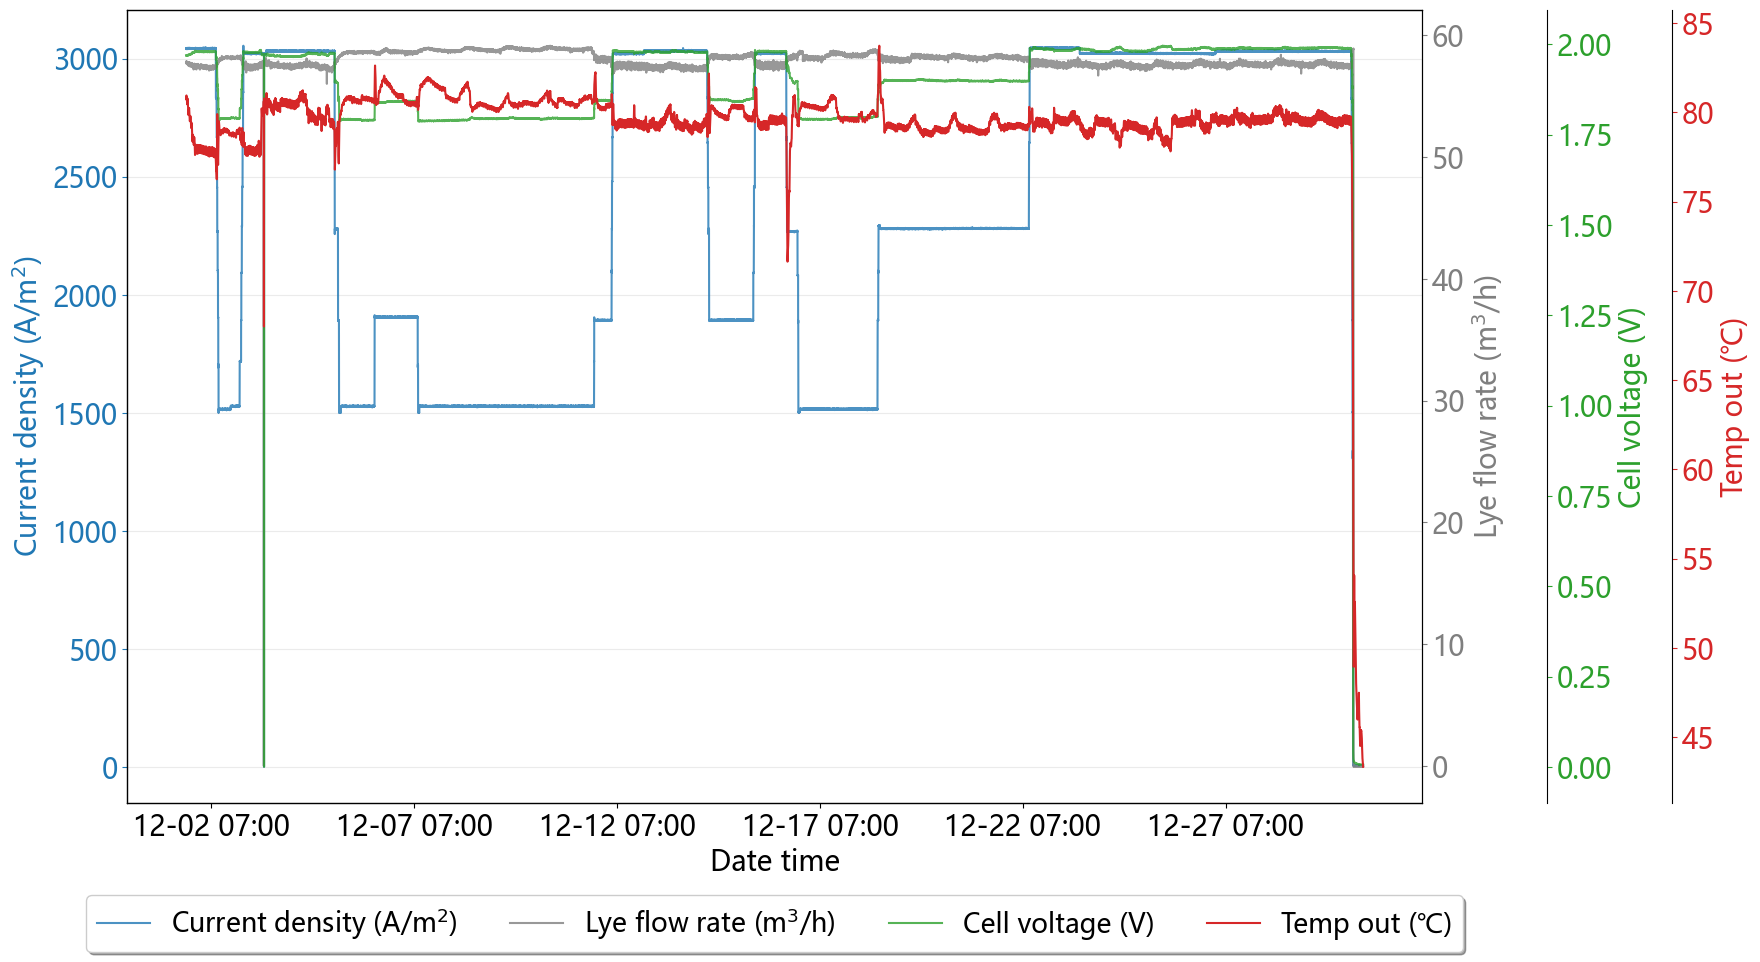

In [5]:
import matplotlib.dates as mdates

# 确保时间列是 datetime，避免 x 轴显示成字符串或序号
df_plot = df_XY.copy()
df_plot[Cols.date_time] = pd.to_datetime(df_plot[Cols.date_time], errors='coerce')
df_plot = df_plot.dropna(subset=[Cols.date_time]).sort_values(Cols.date_time)

# 创建图表和子图
fig, ax1 = plt.subplots(figsize=(18, 10))

# 仅绘制 y 方向网格，降低视觉干扰
ax1.grid(True, axis='y', alpha=0.25)

# 绘制电流密度曲线
ax1.plot(df_plot[Cols.date_time], df_plot[Cols.current_density], c='#1f77b4', alpha=0.8, label='Current density (A/m$^2$)')
ax1.set_ylabel('Current density (A/m$^2$)', color='#1f77b4')
ax1.set_xlabel('Date time')
ax1.tick_params('y', colors='#1f77b4')

# x 轴日期刻度：固定每 6 小时一个刻度，保证时间间隔均匀
locator = mdates.HourLocator(interval=120)  # 每 120 小时（5 天）一个刻度
formatter = mdates.DateFormatter('%m-%d %H:%M')
ax1.xaxis.set_major_locator(locator)
ax1.xaxis.set_major_formatter(formatter)
plt.setp(ax1.get_xticklabels(), rotation=0, ha='center')

# 创建第二个 y 轴
ax2 = ax1.twinx()
ax2.plot(df_plot[Cols.date_time], df_plot[Cols.lye_flow], alpha=0.8, c='#7f7f7f', label='Lye flow rate (m$^3$/h)')
ax2.set_ylabel('Lye flow rate (m$^3$/h)', color='#7f7f7f')
ax2.tick_params('y', colors='#7f7f7f')

# 创建第三个 y 轴
ax3 = ax1.twinx()
ax3.plot(df_plot[Cols.date_time], df_plot[Cols.cell_voltage], c='#2ca02c', alpha=0.8, label='Cell voltage (V)')
ax3.set_ylabel('Cell voltage (V)', color='#2ca02c')
ax3.spines['right'].set_position(('outward', 90))
ax3.tick_params('y', colors='#2ca02c')

# 创建第四个 y 轴
ax4 = ax1.twinx()
ax4.plot(df_plot[Cols.date_time], df_plot[Cols.temp_out], c='#d62728', label='Temp out (℃)')
ax4.set_ylabel('Temp out (℃)', color='#d62728')
ax4.spines['right'].set_position(('outward', 180))
ax4.tick_params('y', colors='#d62728')

# 添加图例
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax1.legend(lines + lines2 + lines3 + lines4, labels + labels2 + labels3 + labels4,
           loc='upper center', fontsize=19, bbox_to_anchor=(0.5, -0.1),
           ncol=4, frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.show()

In [6]:
df_static_XY = df_XY.copy()

In [7]:
# 计算前后 5 个点（窗口大小为 11，即10min）的极差
window_size = 11
df_static_XY['temp_diff'] = df_static_XY[Cols.temp_out].rolling(window=window_size, center=True, min_periods=1).apply(lambda x: x.max() - x.min())

# 筛选出温度变化值小于 0.2 的行
df_static_XY = df_static_XY[df_static_XY['temp_diff'] < 0.2]

# 过滤无效工况，避免后续 log/除法出现 NaN 或 Inf
valid_mask = (
    (df_static_XY[Cols.lye_temp] > 0) &
    (df_static_XY[Cols.temp_out] > 0) &
    (df_static_XY[Cols.current_density] > 0) &
    (df_static_XY[Cols.lye_flow] > 0) &
    (df_static_XY[Cols.pressure] > 0) &
    (df_static_XY[Cols.cell_voltage] > 0)
)
df_static_XY = df_static_XY[valid_mask].copy()

print(f"过滤后样本数: {len(df_static_XY)}")

过滤后样本数: 28963


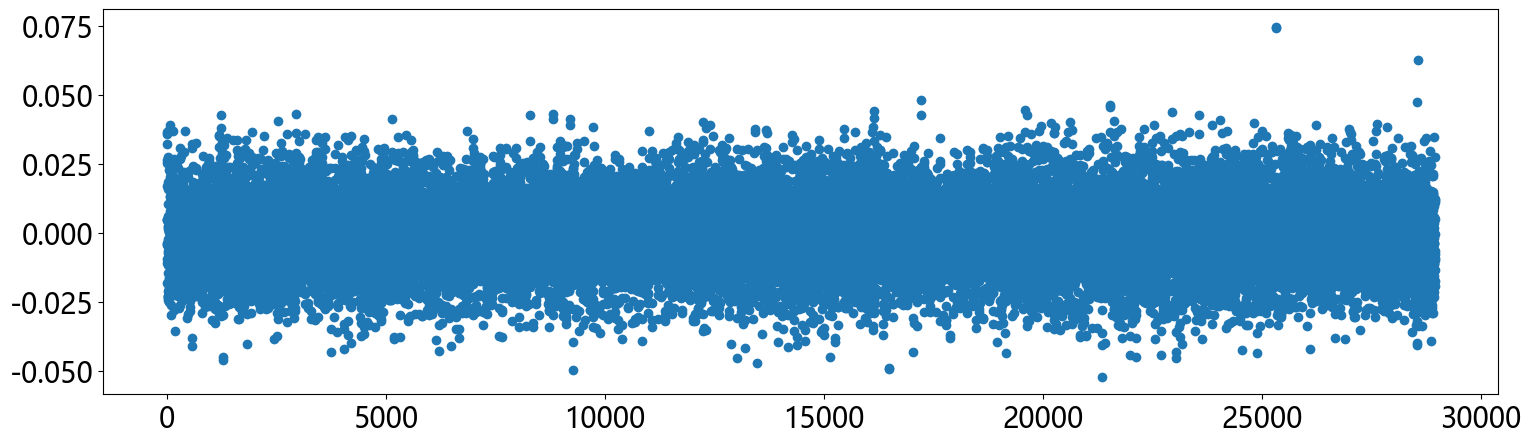

In [8]:
plt.figure(figsize=(18,5))
plt.scatter(range(len(df_static_XY[Cols.delta_temp_out])),df_static_XY[Cols.delta_temp_out])

## 定义拟合函数

In [9]:
# 定义拟合函数（修复版：准稳态，热容不在分母，不发散）
def static_thermal_fit(Statistics, tg1, Surface_heat_transfer_coefficient, Heat_capacity_lye, tc1, tc2, Heat_capacity_stack, Num_cells = 280, Sample_time = 60):
    """稳态热模型函数（适配：微小温度变化 0.0x℃/分钟，不发散）

    Args:
        Statistics (Dataframe): 实验数据
        Surface_heat_transfer_coefficient (float): 电解槽对空气散热的表面传热系数 W/℃
        Heat_capacity_lye (float): 碱液比热容
        tc1 (float): 碱液带入热量修正系数
        tc2 (float): 碱液带出热量修正系数
        Heat_capacity_stack (float): 电解槽比热容
        Num_cells (int, optional): 小室数. Defaults to 280.
        Sample_time (int, optional): 采样时间间隔. Defaults to 60.

    Returns:
        float: 热平衡误差（拟合目标：让误差趋近0，梯度下降绝对稳定）
    """
    cell_voltage = Statistics[0]
    current = Statistics[1]
    temp_out = Statistics[2]
    temp_environment = Statistics[3]
    lye_flow = Statistics[4]
    lye_temp = Statistics[5]
    delta_T_measured = Statistics[6]  # 你实测的温度变化（每分钟 0.0x℃）

    Tref = 25  # 参考点温度: K
    z = 2  # 单位摩尔反应转移的电子数: mol

    Delta_H0_H2O = -2.86E5  # 参考点状态下的焓变(单位：J / mol)
    Delta_H0_H2 = 0  # 参考点状态下的焓变(单位：J / mol)
    Delta_H0_O2 = 0  # 参考点状态下的焓变(单位：J / mol)

    Cp0_H2O = 75  # 参考点状态下的水热容(单位：J / (K * mol))
    Cp0_H2 = 29  # 参考点状态下的氢气热容(单位：J / (K * mol))
    Cp0_O2 = 29  # 参考点状态下的氧气热容(单位：J / (K * mol))

    Delta_H_H2 = Cp0_H2 * (temp_out - Tref) + Delta_H0_H2
    Delta_H_O2 = Cp0_O2 * (temp_out - Tref) + Delta_H0_O2
    Delta_H_H2O = Cp0_H2O * (temp_out - Tref) + Delta_H0_H2O
    Delta_H = Delta_H_H2 + 0.5 * Delta_H_O2 - Delta_H_H2O

    Vtn_cell = Delta_H / (z * 96485)

    lye_flow = lye_flow * 1.328 * 1E6 / 3600 # m3/h → g/s

    Qdot_gen = Num_cells * (cell_voltage - Vtn_cell) * current * tg1 # 单位 W

    Qdot_loss = (temp_out - temp_environment) * Surface_heat_transfer_coefficient # 单位 W

    Qdot_lye_in = Heat_capacity_lye * lye_flow * lye_temp * tc1 # 单位 W

    Qdot_lye_out = Heat_capacity_lye * lye_flow * temp_out * tc2 # 单位 W

    Qdot_cool = Qdot_lye_out - Qdot_lye_in # 单位 W

    # ==================== 唯一修改：核心公式变形（解决发散！） ====================
    # 原来写法（会发散）：delta_Temp_H = (Q_gen - Q_loss - Q_cool) / C_stack
    # 现在写法（稳定）：把热容移到左边，变成乘法，保留微小温度变化
    Qdot_storage = Heat_capacity_stack * delta_T_measured / Sample_time  # 关键：不再除以热容

    # 拟合目标：热平衡误差 → 0
    heat_balance_error = Qdot_gen - (Qdot_loss + Qdot_cool + Qdot_storage)

    return heat_balance_error

## 提取自变量与因变量

In [10]:
# 检查是否有 GPU 可用
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

使用设备: cpu


In [11]:
# 拟合时使用的特征（包含实测温升，用于热平衡残差）
feature_cols_fit = [
    Cols.cell_voltage, Cols.current, Cols.temp_out, Cols.temp_environment,
    Cols.lye_flow, Cols.lye_temp, Cols.delta_temp_out
]
statistics = df_static_XY[feature_cols_fit]

statistics_torch = torch.tensor(statistics.values.T, dtype=torch.float32).to(device)

In [12]:
# 计算训练集和测试集的大小
total_size = statistics_torch.shape[1]
train_size = int(0.8 * total_size)
test_size = total_size - train_size

# 随机划分数据
train_indices, test_indices = random_split(range(total_size), [train_size, test_size])

# 根据划分的索引获取训练集和测试集（每列是一个样本）
statistics_torch_train = statistics_torch[:, train_indices.indices]
statistics_torch_test = statistics_torch[:, test_indices.indices]

print(f"训练集大小: {statistics_torch_train.shape[1]}")
print(f"测试集大小: {statistics_torch_test.shape[1]}")

训练集大小: 23170
测试集大小: 5793


## 拟合经验参数

In [13]:
# 给定值初始化
params1 = {name: torch.tensor(2.2E9, dtype=torch.float32) for name in [
    'Heat_capacity_stack'
]}
params2 = {name: torch.tensor(5000, dtype=torch.float32) for name in [
    'Surface_heat_transfer_coefficient'
]}
params3 = {name: torch.tensor(3.3, dtype=torch.float32) for name in [
    'Heat_capacity_lye'
]}
params4 = {name: torch.tensor(0.9, dtype=torch.float32) for name in [
    'tg1', 'tc1', 'tc2'
]}

params = {**params1, **params2, **params3, **params4}

for param in params.values():
    param.requires_grad = True

params = {k: torch.nn.Parameter(v.to(device)) for k, v in params.items()}

### 梯度下降方法拟合

In [14]:
# 定义损失函数：让热平衡误差逼近 0
class HeatBalanceLoss(torch.nn.Module):
    def __init__(self, scale=1e-6):
        super(HeatBalanceLoss, self).__init__()
        self.scale = scale

    def forward(self, heat_balance_error):
        return torch.mean((heat_balance_error * self.scale) ** 2)

criterion = HeatBalanceLoss(scale=1e-6)

# 分四类设置学习率
lr1 = 1e4
lr2 = 1e1
lr3 = 1e-2
lr4 = 1e-3

# 设置训练边界
tolerance = 1e-6

# 分离参数，按照不同学习率分类
params1_list = [params['Heat_capacity_stack']]
params2_list = [params['Surface_heat_transfer_coefficient']]
params3_list = [params['Heat_capacity_lye']]
params4_list = [params['tg1'], params['tc1'], params['tc2']]

# 使用单个优化器管理多参数组
optimizer = torch.optim.AdamW([
    {'params': params1_list, 'lr': lr1},
    {'params': params2_list, 'lr': lr2},
    {'params': params3_list, 'lr': lr3},
    {'params': params4_list, 'lr': lr4}
], weight_decay=1e-4)

# 早停策略参数
patience = 1000
best_test_loss = float('inf')
counter = 0

# 训练循环
num_epochs = 100000

for epoch in range(num_epochs):
    optimizer.zero_grad()

    # 训练数据前向传播：输出热平衡误差
    heat_balance_error_train = static_thermal_fit(statistics_torch_train, **params)
    train_loss = criterion(heat_balance_error_train)

    # 反向传播与优化
    train_loss.backward()
    optimizer.step()

    # 验证步骤
    with torch.no_grad():
        heat_balance_error_test = static_thermal_fit(statistics_torch_test, **params)
        test_loss = criterion(heat_balance_error_test)

    # 每50个epoch打印信息
    if epoch % 50 == 0:
        print(f'Epoch {epoch}, Train Loss: {train_loss.item():.4e}, Test Loss: {test_loss.item():.4e}')

    # 早停策略
    if test_loss.item() < best_test_loss:
        best_test_loss = test_loss.item()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}, best test loss: {best_test_loss:.4e}")
            break

    # 收敛条件检查
    if train_loss.item() < tolerance:
        print(f"训练损失达到收敛条件 (<{tolerance})")
        break

# 最终结果输出
print("训练完成，最终验证损失：", best_test_loss)

Epoch 0, Train Loss: 5.5181e-01, Test Loss: 3.4396e-01
Epoch 50, Train Loss: 1.3934e-02, Test Loss: 1.3674e-02
Epoch 100, Train Loss: 6.9480e-03, Test Loss: 6.9473e-03
Epoch 150, Train Loss: 4.3270e-03, Test Loss: 4.3379e-03
Epoch 200, Train Loss: 2.5892e-03, Test Loss: 2.6006e-03
Epoch 250, Train Loss: 1.5212e-03, Test Loss: 1.5347e-03
Epoch 300, Train Loss: 9.1515e-04, Test Loss: 9.3034e-04
Epoch 350, Train Loss: 5.9038e-04, Test Loss: 6.0647e-04
Epoch 400, Train Loss: 4.2316e-04, Test Loss: 4.3951e-04
Epoch 450, Train Loss: 3.3920e-04, Test Loss: 3.5549e-04
Epoch 500, Train Loss: 2.9765e-04, Test Loss: 3.1375e-04
Epoch 550, Train Loss: 2.7730e-04, Test Loss: 2.9322e-04
Epoch 600, Train Loss: 2.6755e-04, Test Loss: 2.8335e-04
Epoch 650, Train Loss: 2.6325e-04, Test Loss: 2.7898e-04
Epoch 700, Train Loss: 2.6184e-04, Test Loss: 2.7755e-04
Epoch 750, Train Loss: 2.6205e-04, Test Loss: 2.7778e-04
Epoch 800, Train Loss: 2.6323e-04, Test Loss: 2.7900e-04
Epoch 850, Train Loss: 2.6502e-04,

In [15]:
print(params)

{'Heat_capacity_stack': Parameter containing:
tensor(0.6683, requires_grad=True), 'Surface_heat_transfer_coefficient': Parameter containing:
tensor(1032.2635, requires_grad=True), 'Heat_capacity_lye': Parameter containing:
tensor(2.4218, requires_grad=True), 'tg1': Parameter containing:
tensor(0.9536, requires_grad=True), 'tc1': Parameter containing:
tensor(0.8910, requires_grad=True), 'tc2': Parameter containing:
tensor(0.8943, requires_grad=True)}


In [ ]:
torch.save(params, r'D:\Devs\Simulation-Platform\src\Model\Static_Model\Static_Thermal_params.pth')

## 检查拟合效果

### 预测结果

In [ ]:
params['Heat_capacity_lye'] = torch.nn.Parameter(torch.tensor(3.2, dtype=torch.float32, device=device))
params['Heat_capacity_stack'] = torch.nn.Parameter(torch.tensor(10E5, dtype=torch.float32, device=device))
params['Surface_heat_transfer_coefficient'] = torch.nn.Parameter(torch.tensor(30.5, dtype=torch.float32, device=device))
params['tg1'] = torch.nn.Parameter(torch.tensor(1, dtype=torch.float32, device=device))
params['tc1'] = torch.nn.Parameter(torch.tensor(1.01, dtype=torch.float32, device=device))
params['tc2'] = torch.nn.Parameter(torch.tensor(0.95, dtype=torch.float32, device=device))

heat_balance_error_train = static_thermal_fit(statistics_torch_train, **params)
train_loss = criterion(heat_balance_error_train)
heat_balance_error_test = static_thermal_fit(statistics_torch_test, **params)
test_loss = criterion(heat_balance_error_test)
print(train_loss, test_loss)

tensor(40638216., device='cuda:0', grad_fn=<MulBackward0>) tensor(41334444., device='cuda:0', grad_fn=<MulBackward0>)


Text(0, 0.5, '温度')

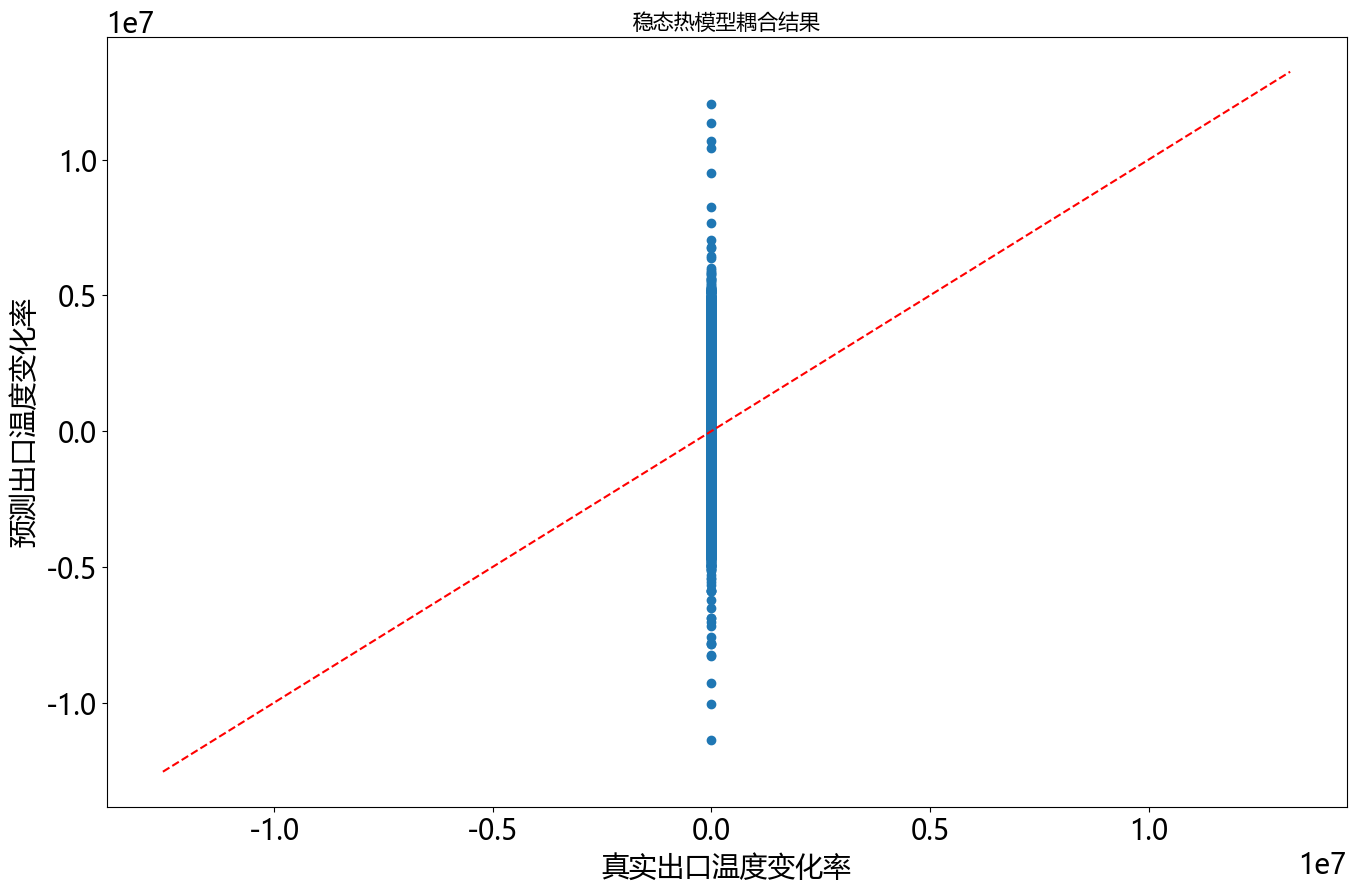

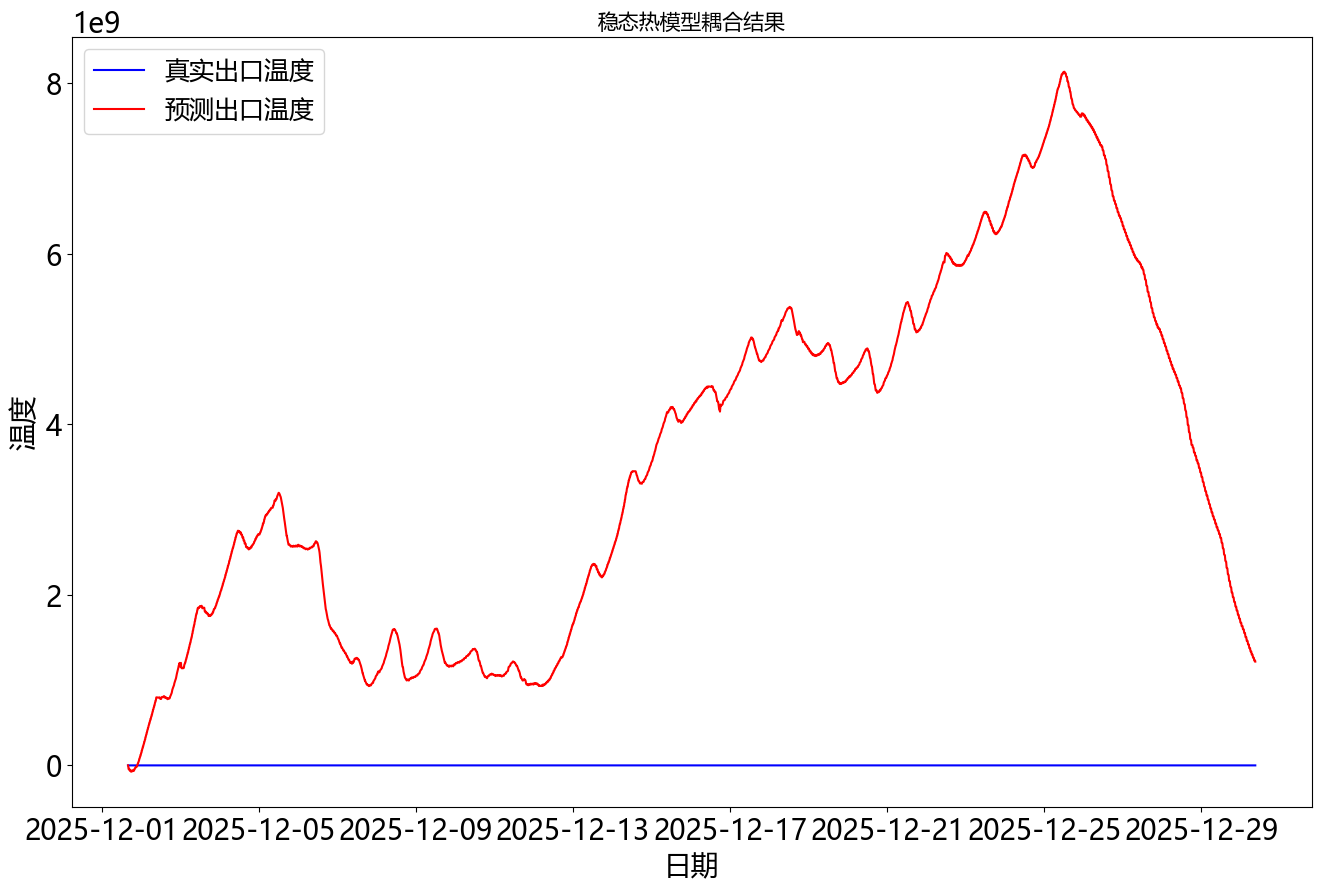

In [16]:
def predict_delta_temp_from_balance(Statistics, tg1, Surface_heat_transfer_coefficient, Heat_capacity_lye, tc1, tc2, Heat_capacity_stack, Num_cells=280, Sample_time=60):
    """基于热平衡方程反推出口温度变化率（不使用实测 delta_T）"""
    cell_voltage = Statistics[0]
    current = Statistics[1]
    temp_out = Statistics[2]
    temp_environment = Statistics[3]
    lye_flow = Statistics[4]
    lye_temp = Statistics[5]

    Tref = 25
    z = 2
    Delta_H0_H2O = -2.86E5
    Delta_H0_H2 = 0
    Delta_H0_O2 = 0
    Cp0_H2O = 75
    Cp0_H2 = 29
    Cp0_O2 = 29

    Delta_H_H2 = Cp0_H2 * (temp_out - Tref) + Delta_H0_H2
    Delta_H_O2 = Cp0_O2 * (temp_out - Tref) + Delta_H0_O2
    Delta_H_H2O = Cp0_H2O * (temp_out - Tref) + Delta_H0_H2O
    Delta_H = Delta_H_H2 + 0.5 * Delta_H_O2 - Delta_H_H2O
    Vtn_cell = Delta_H / (z * 96485)

    lye_flow = lye_flow * 1.328 * 1E6 / 3600
    Qdot_gen = Num_cells * (cell_voltage - Vtn_cell) * current * tg1
    Qdot_loss = (temp_out - temp_environment) * Surface_heat_transfer_coefficient
    Qdot_lye_in = Heat_capacity_lye * lye_flow * lye_temp * tc1
    Qdot_lye_out = Heat_capacity_lye * lye_flow * temp_out * tc2
    Qdot_cool = Qdot_lye_out - Qdot_lye_in

    delta_temp_pred = (Qdot_gen - Qdot_loss - Qdot_cool) * Sample_time / Heat_capacity_stack
    return delta_temp_pred

feature_cols_predict = [
    Cols.cell_voltage, Cols.current, Cols.temp_out,
    Cols.temp_environment, Cols.lye_flow, Cols.lye_temp
]
statistics_simulation = df_static_XY[feature_cols_predict]
statistics_simulation_torch = torch.tensor(statistics_simulation.values.T, dtype=torch.float32).to(device)

delta_temp_out_pred = predict_delta_temp_from_balance(Statistics=statistics_simulation_torch, **params)
delta_temp_out_pred = delta_temp_out_pred.cpu().detach().numpy()

initial_temperature = df_static_XY[Cols.temp_out].iloc[0]
pre_temp_out = initial_temperature + delta_temp_out_pred.cumsum()

plt.figure(figsize = (16, 10))
plt.scatter(df_static_XY[Cols.delta_temp_out], delta_temp_out_pred)

ax = plt.gca()
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
diag_min = min(x_min, y_min)
diag_max = max(x_max, y_max)
plt.plot([diag_min, diag_max], [diag_min, diag_max], color='red', linestyle='--')
plt.title('稳态热模型耦合结果', fontsize = 15)
plt.xlabel('真实出口温度变化率')
plt.ylabel('预测出口温度变化率')

plt.figure(figsize = (16, 10))
plt.plot(df_static_XY[Cols.date_time],df_static_XY[Cols.temp_out], c = 'b', label = '真实出口温度')
plt.plot(df_static_XY[Cols.date_time],pre_temp_out, c = 'r', label = '预测出口温度')
plt.legend()
plt.title('稳态热模型耦合结果', fontsize = 15)
plt.xlabel('日期')
plt.ylabel('温度')

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(df_static_XY[Cols.delta_temp_out], delta_temp_out_pred)
print(r2)

-65908.08674284177


In [ ]:
from scipy.stats import gaussian_kde

# 计算核密度估计
x = df_static_XY[Cols.delta_temp_out]
y = delta_temp_out_pred
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# 按密度排序以确保高密度点显示在上方
idx = z.argsort()
x, y, z = x.iloc[idx], y.iloc[idx], z[idx]

Text(0.09, -0.075, 'R$^2$=0.922\nMSE=7.477E-5')

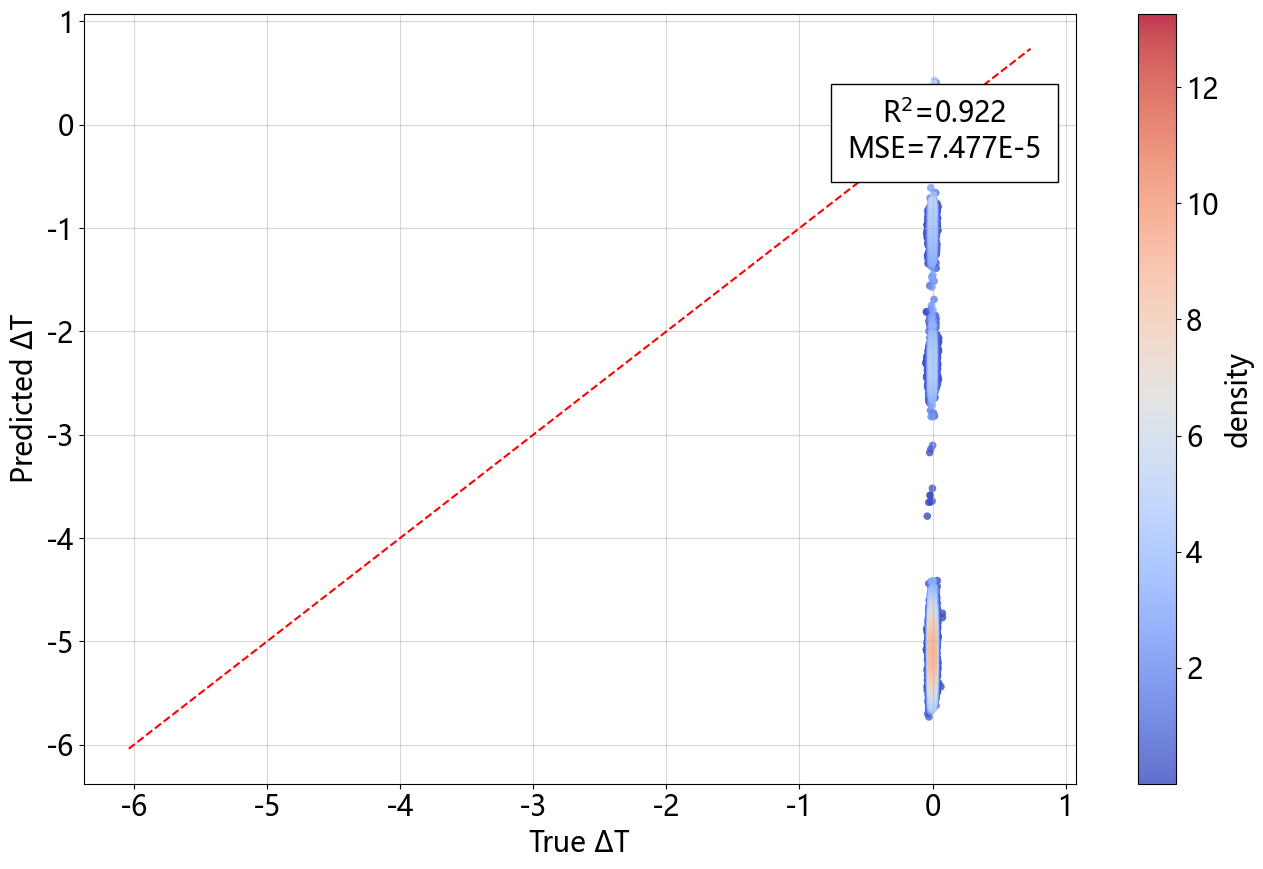

In [20]:
# 绘制散点图，颜色映射到密度
plt.figure(figsize=(16, 10))
sc = plt.scatter(
    x, y,
    c=z,
    s=30,               # 点大小
    cmap='coolwarm',     # 颜色映射
    edgecolor='none',   # 无边框
    alpha=0.8           # 透明度
)
plt.colorbar(sc, label='density')  # 添加颜色条

# 其余代码保持不变
ax = plt.gca()
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
diag_min = min(x_min, y_min)
diag_max = max(x_max, y_max)
plt.plot([diag_min, diag_max], [diag_min, diag_max], color='red', linestyle='--')
# plt.title('稳态热模型耦合结果', fontproperties=prop, fontsize=15)
plt.xlabel('True ΔT')
plt.ylabel('Predicted ΔT')

plt.grid(True, alpha=0.5)
# plt.text(0.09, -0.075, 'R$^2$=0.922', va='center', ha='center', fontsize=20)
# plt.text(0.09, -0.085, 'MSE=7.477E-5', va='center', ha='center', fontsize=20)

# 绘制空白框并添加文本
plt.text(
    x=0.09, y=-0.075,  # 文本框中心坐标（相对画布比例，0-1范围）
    s="R$^2$=0.922\nMSE=7.477E-5",  # 文本内容
    fontsize=20,    # 字体大小
    ha='center',    # 水平居中
    va='center',    # 垂直居中
    bbox=dict(      # 空白框样式设置
        facecolor='white',  # 框内填充色（白色=空白）
        edgecolor='black',  # 边框颜色
        boxstyle='square,pad=0.6'  # 框样式（round=圆角，pad=内边距）
    )
)